
# Car Sales Price Prediction using Linear Regression

## Objective

In this notebook, we will build a **Linear Regression model** to predict car `Price`.

We will cover:

1. Load and understand the car sales dataset
2. Basic data cleaning
3. Feature engineering
4. Outlier detection and removal
5. Train-test split
6. Linear Regression model using `sklearn`
7. Model performance metrics
8. Linear Regression assumption checking
9. Final interpretation

---

## Target Variable

We will predict:

```text
Price
```

## Important Note

Linear Regression is not only about fitting a model.  
We should also check whether the assumptions are reasonably satisfied.


In [1]:

# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Statistical tests and diagnostics
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor





# 1. Load Dataset

The dataset used in this notebook is `car_sales.csv`.


In [2]:

# Load dataset

df = pd.read_csv("car_sales.csv")

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (93, 28)


,Unnamed: 0,Manufacturer,Model,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,...,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin,Make
0,1,Acura,Integra,Small,12.9,15.9,18.8,25,31,None,...,5,177,102,68,37,26.5,11.0,2705,non-USA,Acura Integra
1,2,Acura,Legend,Midsize,29.2,33.9,38.7,18,25,Driver & Passenger,...,5,195,115,71,38,30.0,15.0,3560,non-USA,Acura Legend
2,3,Audi,90,Compact,25.9,29.1,32.3,20,26,Driver only,...,5,180,102,67,37,28.0,14.0,3375,non-USA,Audi 90
3,4,Audi,100,Midsize,30.8,37.7,44.6,19,26,Driver & Passenger,...,6,193,106,70,37,31.0,17.0,3405,non-USA,Audi 100
4,5,BMW,535i,Midsize,23.7,30.0,36.2,22,30,Driver only,...,4,186,109,69,39,27.0,13.0,3640,non-USA,BMW 535i


In [3]:

# Check columns and data types

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          93 non-null     int64  
 1   Manufacturer        93 non-null     object 
 2   Model               93 non-null     object 
 3   Type                93 non-null     object 
 4   Min.Price           93 non-null     float64
 5   Price               93 non-null     float64
 6   Max.Price           93 non-null     float64
 7   MPG.city            93 non-null     int64  
 8   MPG.highway         93 non-null     int64  
 9   AirBags             93 non-null     object 
 10  DriveTrain          93 non-null     object 
 11  Cylinders           93 non-null     object 
 12  EngineSize          93 non-null     float64
 13  Horsepower          93 non-null     int64  
 14  RPM                 93 non-null     int64  
 15  Rev.per.mile        93 non-null     int64  
 16  Man.trans.

In [4]:

# Summary statistics

df.describe()


,Unnamed: 0,Min.Price,Price,Max.Price,MPG.city,MPG.highway,EngineSize,Horsepower,RPM,Rev.per.mile,Fuel.tank.capacity,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight
count,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,91.000000,82.000000,93.000000
mean,47.000000,17.125806,19.509677,21.898925,22.365591,29.086022,2.667742,143.827957,5280.645161,2332.204301,16.664516,5.086022,183.204301,103.946237,69.376344,38.956989,27.829670,13.890244,3072.903226
std,26.990739,8.746029,9.659430,11.030457,5.619812,5.331726,1.037363,52.374410,596.731690,496.506525,3.279370,1.038979,14.602382,6.819674,3.778986,3.223265,2.989072,2.997967,589.896510
min,1.000000,6.700000,7.400000,7.900000,15.000000,20.000000,1.000000,55.000000,3800.000000,1320.000000,9.200000,2.000000,141.000000,90.000000,60.000000,32.000000,19.000000,6.000000,1695.000000
25%,24.000000,10.800000,12.200000,14.700000,18.000000,26.000000,1.800000,103.000000,4800.000000,1985.000000,14.500000,4.000000,174.000000,98.000000,67.000000,37.000000,26.000000,12.000000,2620.000000
50%,47.000000,14.700000,17.700000,19.600000,21.000000,28.000000,2.400000,140.000000,5200.000000,2340.000000,16.400000,5.000000,183.000000,103.000000,69.000000,39.000000,27.500000,14.000000,3040.000000
75%,70.000000,20.300000,23.300000,25.300000,25.000000,31.000000,3.300000,170.000000,5750.000000,2565.000000,18.800000,6.000000,192.000000,110.000000,72.000000,41.000000,30.000000,15.000000,3525.000000
max,93.000000,45.400000,61.900000,80.000000,46.000000,50.000000,5.700000,300.000000,6500.000000,3755.000000,27.000000,8.000000,219.000000,119.000000,78.000000,45.000000,36.000000,22.000000,4105.000000


In [5]:

# Check missing values

missing_values = df.isnull().sum()
missing_values[missing_values > 0]


Rear.seat.room     2
Luggage.room      11
dtype: int64


# 2. Data Cleaning

We will remove columns that are not useful for modeling.

Examples:

| Column | Reason |
|---|---|
| `Unnamed: 0` | Index-like column |
| `Make` | Combination of manufacturer and model; high-cardinality text |
| `Model` | Too many unique text values for beginner-level model |

We will keep useful categorical variables like:

- `Manufacturer`
- `Type`
- `AirBags`
- `DriveTrain`
- `Man.trans.avail`
- `Origin`

Missing values will be handled later using a preprocessing pipeline.


In [6]:

# Drop unnecessary columns if they exist

drop_cols = ["Unnamed: 0", "Make", "Model"]

df_clean = df.drop(columns=[col for col in drop_cols if col in df.columns])

print("Shape after dropping columns:", df_clean.shape)
df_clean.head()


Shape after dropping columns: (93, 25)


,Manufacturer,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,DriveTrain,Cylinders,...,Fuel.tank.capacity,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin
0,Acura,Small,12.9,15.9,18.8,25,31,None,Front,4,...,13.2,5,177,102,68,37,26.5,11.0,2705,non-USA
1,Acura,Midsize,29.2,33.9,38.7,18,25,Driver & Passenger,Front,6,...,18.0,5,195,115,71,38,30.0,15.0,3560,non-USA
2,Audi,Compact,25.9,29.1,32.3,20,26,Driver only,Front,6,...,16.9,5,180,102,67,37,28.0,14.0,3375,non-USA
3,Audi,Midsize,30.8,37.7,44.6,19,26,Driver & Passenger,Front,6,...,21.1,6,193,106,70,37,31.0,17.0,3405,non-USA
4,BMW,Midsize,23.7,30.0,36.2,22,30,Driver only,Rear,4,...,21.1,4,186,109,69,39,27.0,13.0,3640,non-USA



# 3. Exploratory Data Analysis

Before modeling, let us understand the target variable `Price`.


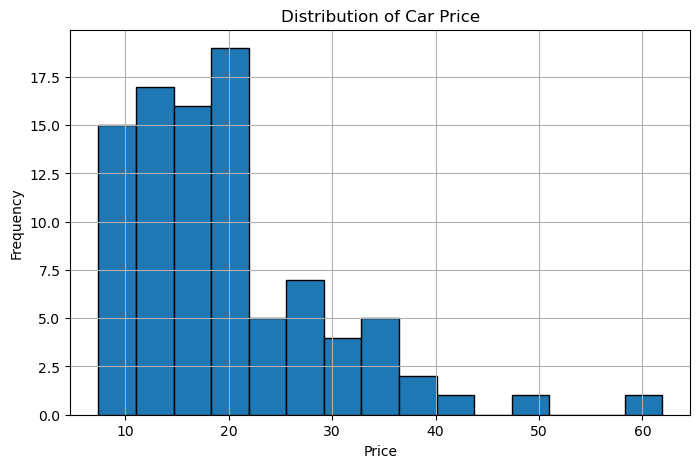

In [7]:

# Distribution of Price

plt.figure(figsize=(8, 5))
plt.hist(df_clean["Price"], bins=15, edgecolor="black")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Car Price")
plt.grid(True)
plt.show()


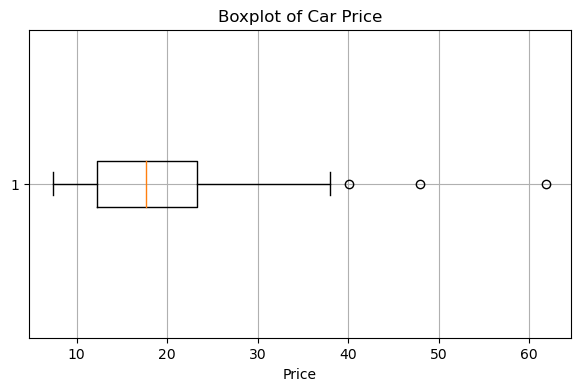

In [8]:

# Boxplot of Price

plt.figure(figsize=(7, 4))
plt.boxplot(df_clean["Price"].dropna(), vert=False)
plt.xlabel("Price")
plt.title("Boxplot of Car Price")
plt.grid(True)
plt.show()


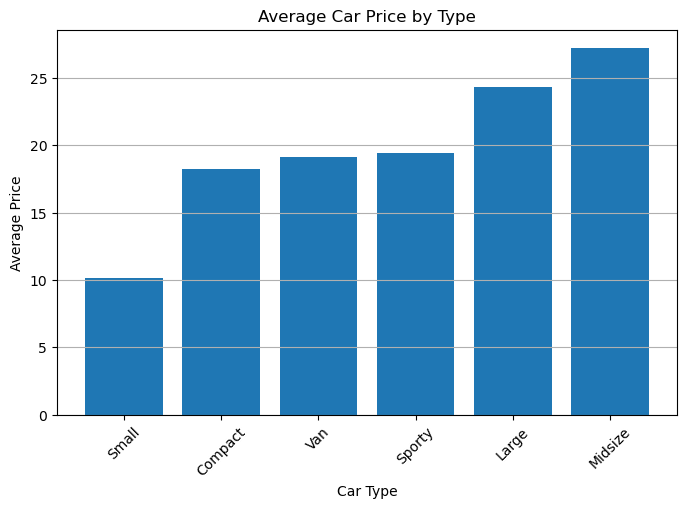

In [9]:

# Average price by car type

price_by_type = df_clean.groupby("Type")["Price"].mean().sort_values()

plt.figure(figsize=(8, 5))
plt.bar(price_by_type.index, price_by_type.values)
plt.xlabel("Car Type")
plt.ylabel("Average Price")
plt.title("Average Car Price by Type")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()



# 4. Feature Engineering

Feature engineering means creating new useful columns from existing columns.

We will create:

| New Feature | Formula | Meaning |
|---|---|---|
| `Price_Range` | `Max.Price - Min.Price` | Difference between max and min price |
| `Avg_MPG` | `(MPG.city + MPG.highway) / 2` | Average mileage |
| `Power_to_Weight` | `Horsepower / Weight` | Power relative to car weight |
| `Is_Manual` | Yes/No converted to 1/0 | Manual transmission availability |


In [10]:

# Feature engineering

df_fe = df_clean.copy()

df_fe["Price_Range"] = df_fe["Max.Price"] - df_fe["Min.Price"]
df_fe["Avg_MPG"] = (df_fe["MPG.city"] + df_fe["MPG.highway"]) / 2
df_fe["Power_to_Weight"] = df_fe["Horsepower"] / df_fe["Weight"]
df_fe["Is_Manual"] = df_fe["Man.trans.avail"].map({"Yes": 1, "No": 0})

df_fe[["Price_Range", "Avg_MPG", "Power_to_Weight", "Is_Manual"]].head()


,Price_Range,Avg_MPG,Power_to_Weight,Is_Manual
0,5.9,28.0,0.051756,1
1,9.5,21.5,0.056180,1
2,6.4,23.0,0.050963,1
3,13.8,22.5,0.050514,1
4,12.5,26.0,0.057143,1



# 5. Outlier Detection and Removal

Outliers can strongly affect Linear Regression.

We will use the **IQR method** on the target variable `Price`.

## IQR Rule

```text
IQR = Q3 - Q1

Lower Limit = Q1 - 1.5 * IQR
Upper Limit = Q3 + 1.5 * IQR
```

Values outside this range are treated as potential outliers.


In [11]:

# IQR method for Price outliers

Q1 = df_fe["Price"].quantile(0.25)
Q3 = df_fe["Price"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

outliers = df_fe[(df_fe["Price"] < lower_limit) | (df_fe["Price"] > upper_limit)]
print("Number of outliers:", outliers.shape[0])

outliers[["Manufacturer", "Type", "Price"]].head()


Q1: 12.2
Q3: 23.3
IQR: 11.100000000000001
Lower Limit: -4.450000000000003
Upper Limit: 39.95
Number of outliers: 3


,Manufacturer,Type,Price
10,Cadillac,Midsize,40.1
47,Infiniti,Midsize,47.9
58,Mercedes-Benz,Midsize,61.9


In [12]:

# Remove Price outliers

df_model = df_fe[(df_fe["Price"] >= lower_limit) & (df_fe["Price"] <= upper_limit)].copy()

print("Original shape:", df_fe.shape)
print("Shape after outlier removal:", df_model.shape)


Original shape: (93, 29)
Shape after outlier removal: (90, 29)


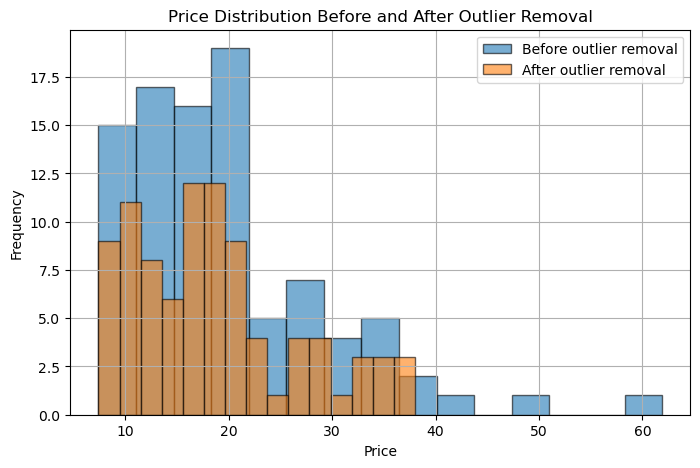

In [13]:

# Compare Price distribution before and after outlier removal

plt.figure(figsize=(8, 5))
plt.hist(df_fe["Price"], bins=15, alpha=0.6, label="Before outlier removal", edgecolor="black")
plt.hist(df_model["Price"], bins=15, alpha=0.6, label="After outlier removal", edgecolor="black")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution Before and After Outlier Removal")
plt.legend()
plt.grid(True)
plt.show()



# 6. Select Features and Target

We will predict `Price`.

We should not use `Min.Price` and `Max.Price` as predictors because they are directly related to `Price` and may cause data leakage.

So we will drop:

- `Price`
- `Min.Price`
- `Max.Price`

We will use remaining useful columns as features.


In [14]:

# Define target and features

target = "Price"

columns_to_remove = ["Price", "Min.Price", "Max.Price"]

X = df_model.drop(columns=[col for col in columns_to_remove if col in df_model.columns])
y = df_model[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

X.head()


Feature shape: (90, 26)
Target shape: (90,)


,Manufacturer,Type,MPG.city,MPG.highway,AirBags,DriveTrain,Cylinders,EngineSize,Horsepower,RPM,...,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin,Price_Range,Avg_MPG,Power_to_Weight,Is_Manual
0,Acura,Small,25,31,None,Front,4,1.8,140,6300,...,68,37,26.5,11.0,2705,non-USA,5.9,28.0,0.051756,1
1,Acura,Midsize,18,25,Driver & Passenger,Front,6,3.2,200,5500,...,71,38,30.0,15.0,3560,non-USA,9.5,21.5,0.056180,1
2,Audi,Compact,20,26,Driver only,Front,6,2.8,172,5500,...,67,37,28.0,14.0,3375,non-USA,6.4,23.0,0.050963,1
3,Audi,Midsize,19,26,Driver & Passenger,Front,6,2.8,172,5500,...,70,37,31.0,17.0,3405,non-USA,13.8,22.5,0.050514,1
4,BMW,Midsize,22,30,Driver only,Rear,4,3.5,208,5700,...,69,39,27.0,13.0,3640,non-USA,12.5,26.0,0.057143,1


In [15]:
inf_count = X.replace([np.inf, -np.inf], np.nan).isna().sum() - X.isna().sum()
inf_count

Manufacturer          0
Type                  0
MPG.city              0
MPG.highway           0
AirBags               0
DriveTrain            0
Cylinders             0
EngineSize            0
Horsepower            0
RPM                   0
Rev.per.mile          0
Man.trans.avail       0
Fuel.tank.capacity    0
Passengers            0
Length                0
Wheelbase             0
Width                 0
Turn.circle           0
Rear.seat.room        0
Luggage.room          0
Weight                0
Origin                0
Price_Range           0
Avg_MPG               0
Power_to_Weight       0
Is_Manual             0
dtype: int64


# 7. Train-Test Split

We divide data into:

| Dataset | Purpose |
|---|---|
| Training data | Used to train the model |
| Testing data | Used to evaluate model performance on unseen data |

We will use 80% data for training and 20% for testing.


In [16]:

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (72, 26)
X_test shape: (18, 26)
y_train shape: (72,)
y_test shape: (18,)



# 8. Preprocessing Pipeline

Our dataset has two types of columns:

1. Numerical columns
2. Categorical columns

For numerical columns:

- Fill missing values with median
- Scale features using StandardScaler

For categorical columns:

- Fill missing values with most frequent value
- Convert categories into numerical columns using OneHotEncoder


In [17]:

# Identify numerical and categorical columns

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)


Numerical features: ['MPG.city', 'MPG.highway', 'EngineSize', 'Horsepower', 'RPM', 'Rev.per.mile', 'Fuel.tank.capacity', 'Passengers', 'Length', 'Wheelbase', 'Width', 'Turn.circle', 'Rear.seat.room', 'Luggage.room', 'Weight', 'Price_Range', 'Avg_MPG', 'Power_to_Weight', 'Is_Manual']
Categorical features: ['Manufacturer', 'Type', 'AirBags', 'DriveTrain', 'Cylinders', 'Man.trans.avail', 'Origin']


In [18]:

# Create preprocessing pipelines

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)



# 9. Apply Linear Regression Model using sklearn

Now we will create a complete pipeline:

```text
Preprocessing + Linear Regression
```


In [19]:

# Create Linear Regression pipeline

linear_regression_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train model
linear_regression_model.fit(X_train, y_train)

# Predict on test data
y_pred = linear_regression_model.predict(X_test)

print("Model training completed.")


Model training completed.



# 10. Model Performance Metrics

We will calculate:

| Metric | Meaning |
|---|---|
| MAE | Average absolute prediction error |
| MSE | Average squared prediction error |
| RMSE | Error in same unit as target variable |
| R-squared | Percentage of variation explained by model |


In [20]:

# Calculate performance metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R-squared"],
    "Value": [mae, mse, rmse, r2]
})

metrics_df


,Metric,Value
0,MAE,4.604506
1,MSE,42.238397
2,RMSE,6.499107
3,R-squared,-0.159891



## Metric Interpretation

| Metric | How to Interpret |
|---|---|
| MAE | On average, prediction is wrong by this much price value |
| RMSE | Similar to MAE but gives more penalty to large errors |
| R-squared | Higher is better; close to 1 means model explains more variation |

For example:

```text
R-squared = 0.80
```

means:

```text
Model explains 80% variation in car price.
```


In [21]:

# Actual vs predicted result table

results_df = pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": y_pred,
    "Error": y_test.values - y_pred
})

results_df.head(10)


,Actual_Price,Predicted_Price,Error
0,12.1,16.655542,-4.555542
1,11.3,11.187768,0.112232
2,31.9,10.654321,21.245679
3,11.1,6.819604,4.280396
4,15.9,15.546167,0.353833
5,25.8,20.350854,5.449146
6,19.8,17.796167,2.003833
7,16.3,17.405542,-1.105542
8,13.4,12.366479,1.033521
9,10.0,13.968042,-3.968042



# 11. Linear Regression Assumptions

We will check these assumptions:

| Assumption | How to Check |
|---|---|
| Linearity | Actual vs predicted plot and residual plot |
| Normality of residuals | Histogram, Q-Q plot, Shapiro-Wilk test |
| Homoscedasticity | Residuals vs predicted plot, Breusch-Pagan test |
| Independence of errors | Durbin-Watson statistic |
| No multicollinearity | VIF |
| No extreme influential outliers | Boxplot and residual review |

Since our final model is built using `sklearn`, we will check assumptions using predictions and residuals.


In [22]:

# Create residuals

residuals = y_test.values - y_pred

diagnostics_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Residual": residuals
})

diagnostics_df.head()


,Actual,Predicted,Residual
0,12.1,16.655542,-4.555542
1,11.3,11.187768,0.112232
2,31.9,10.654321,21.245679
3,11.1,6.819604,4.280396
4,15.9,15.546167,0.353833



# Assumption 1: Linearity

## Meaning

The relationship between input variables and target should be approximately linear.



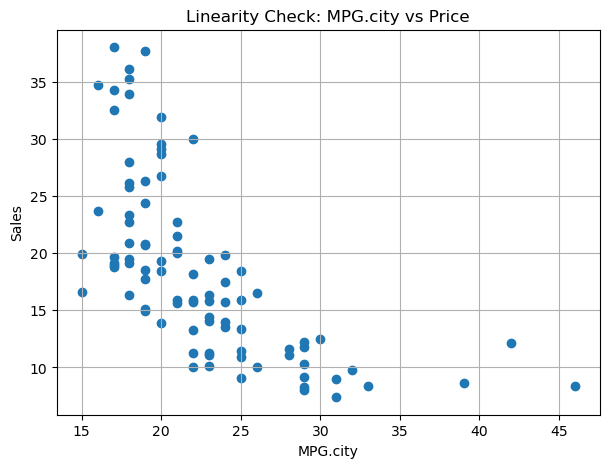

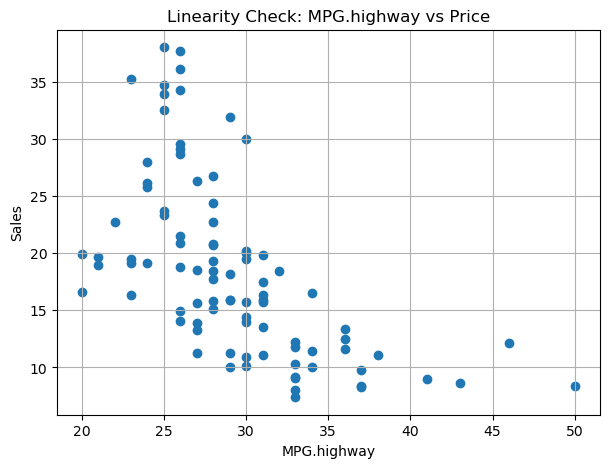

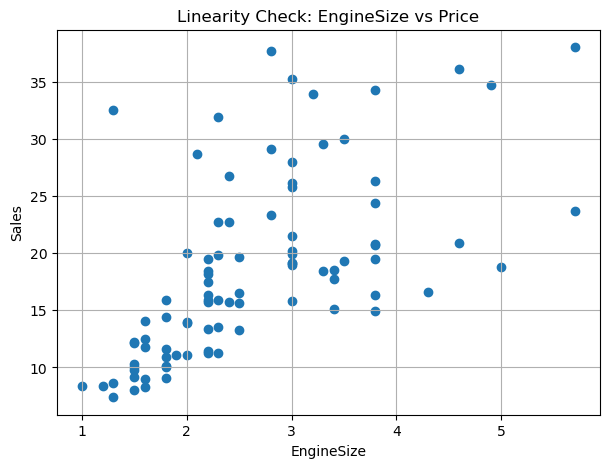

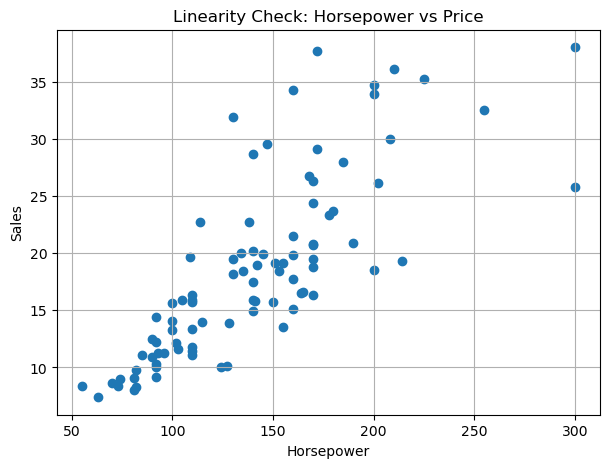

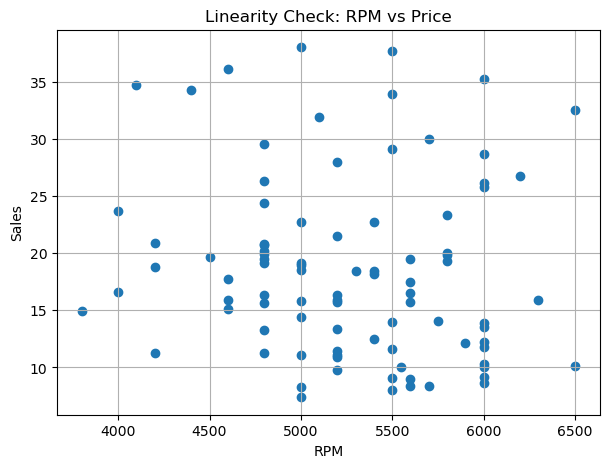

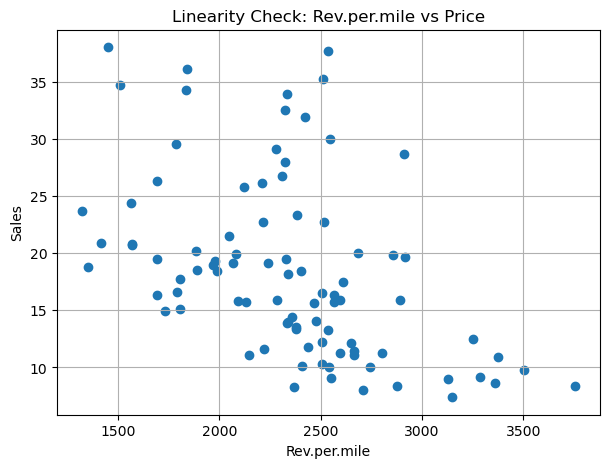

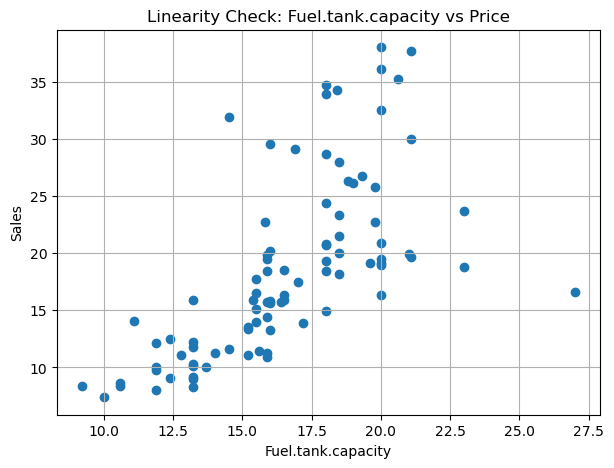

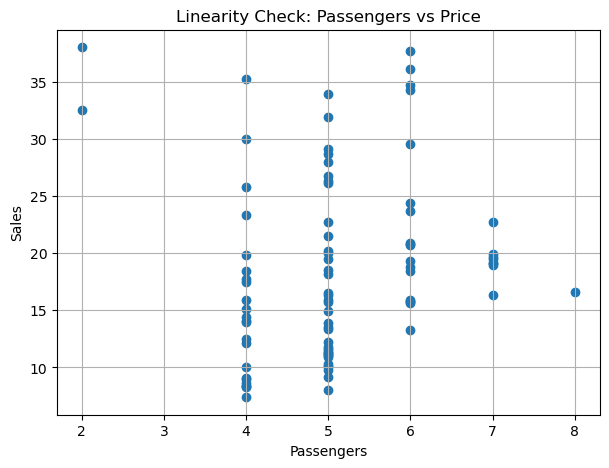

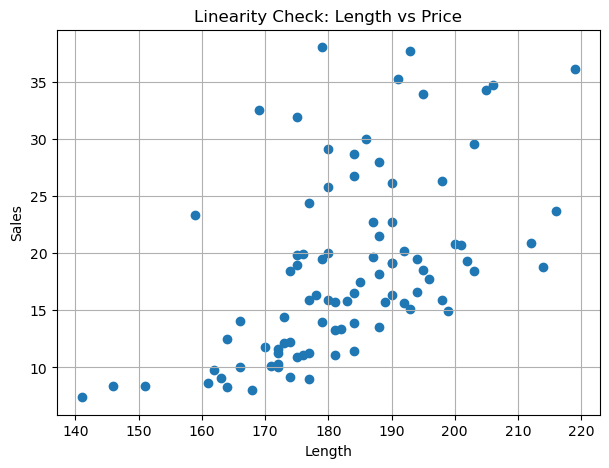

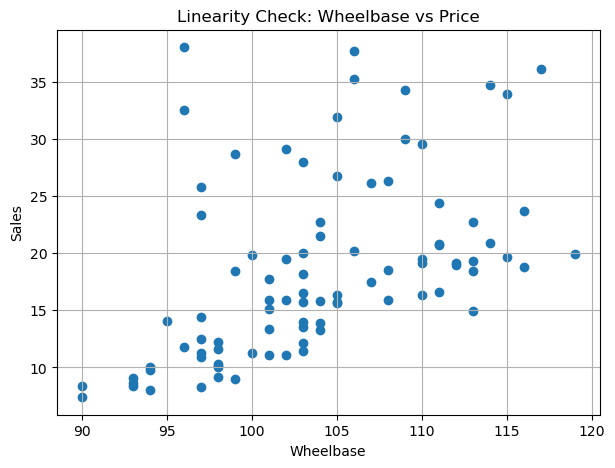

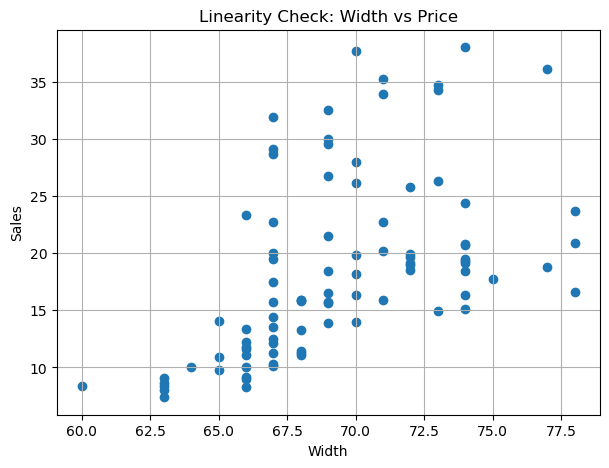

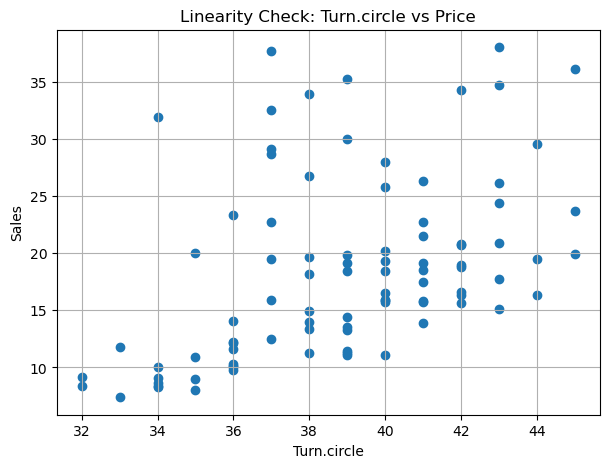

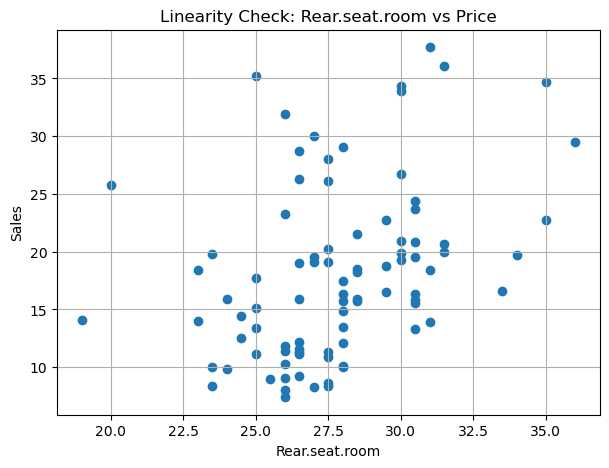

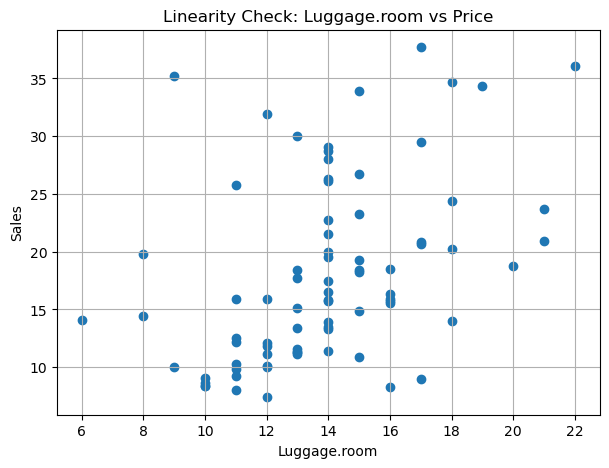

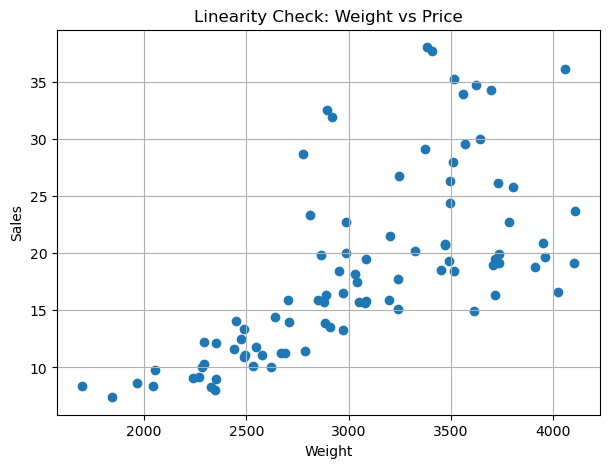

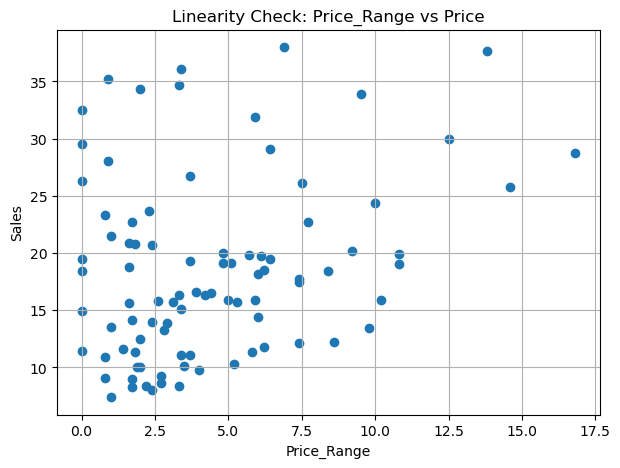

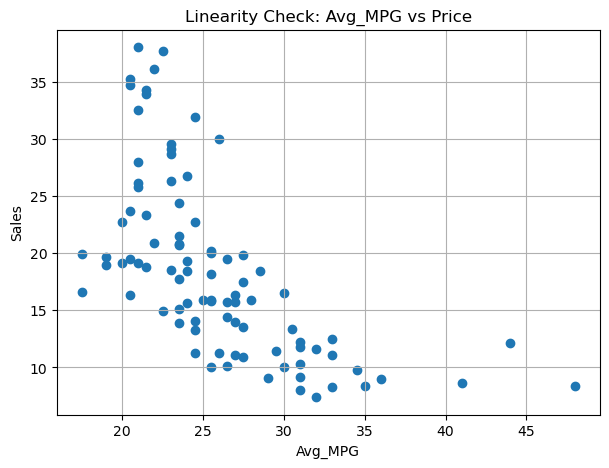

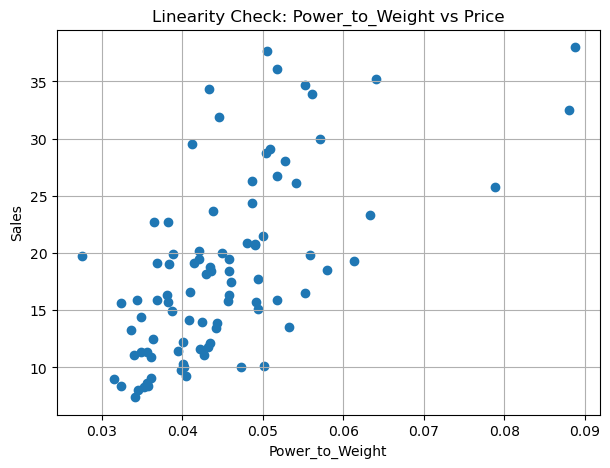

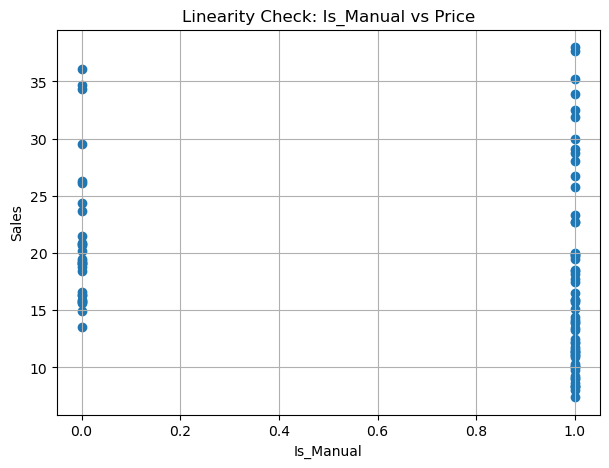

In [23]:
# Linearity check using scatter plots


for feature in numeric_features:
    plt.figure(figsize=(7, 5))
    plt.scatter(X[feature], y)
    plt.xlabel(feature)
    plt.ylabel("Sales")
    plt.title(f"Linearity Check: {feature} vs Price")
    plt.grid(True)
    plt.show()



# Assumption 2: Normality of Residuals

## Meaning

Residuals should be approximately normally distributed.

We will check using:

1. Histogram
2. Q-Q plot
3. Shapiro-Wilk test


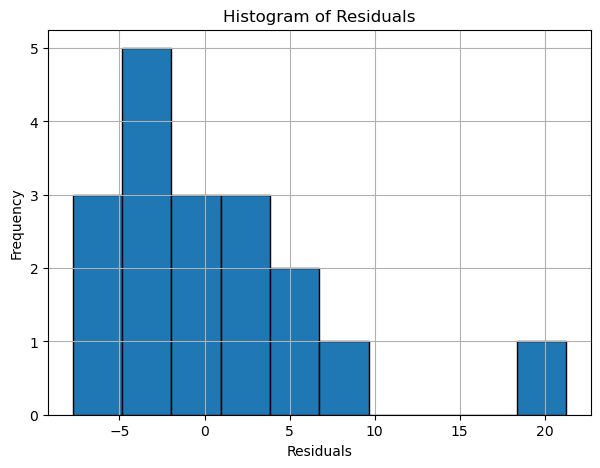

In [24]:

# Histogram of residuals

plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=10, edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.grid(True)
plt.show()


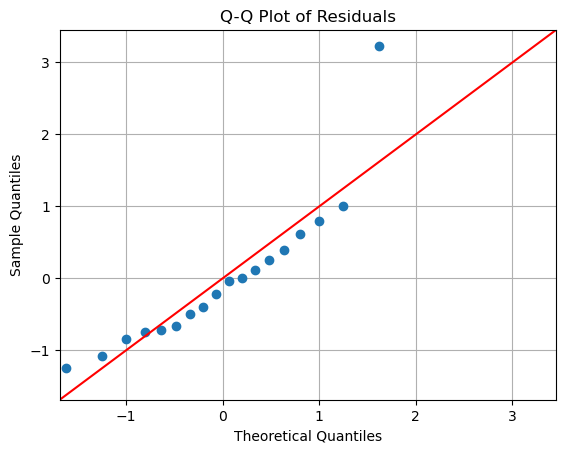

In [25]:

# Q-Q plot of residuals

sm.qqplot(residuals, line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.grid(True)
plt.show()


In [26]:

# Shapiro-Wilk test

shapiro_stat, shapiro_p = stats.shapiro(residuals)

print("Shapiro-Wilk Statistic:", shapiro_stat)
print("p-value:", shapiro_p)

if shapiro_p < 0.05:
    print("Residuals are not normally distributed.")
else:
    print("Residuals are approximately normally distributed.")


Shapiro-Wilk Statistic: 0.8488013744354248
p-value: 0.008108512498438358
Residuals are not normally distributed.



# Assumption 3: Homoscedasticity

## Meaning

Residuals should have constant variance.

## Good sign

Residuals should be randomly scattered around zero without a funnel pattern.


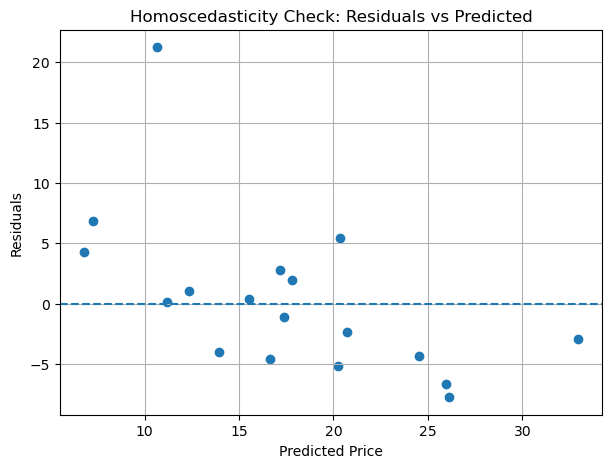

In [27]:

# Residuals vs predicted values

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Homoscedasticity Check: Residuals vs Predicted")
plt.grid(True)
plt.show()



# Assumption 4: Independence of Errors

## Meaning

Residuals should be independent of each other.

We use **Durbin-Watson statistic**.

| Durbin-Watson Value | Meaning |
|---|---|
| Around 2 | Errors are independent |
| Close to 0 | Positive autocorrelation |
| Close to 4 | Negative autocorrelation |


In [28]:

# Durbin-Watson statistic

dw_value = durbin_watson(residuals)

print("Durbin-Watson statistic:", dw_value)


Durbin-Watson statistic: 1.4324409888714096



# Assumption 5: No Multicollinearity

## Meaning

Independent variables should not be highly correlated with each other.

We check this using **VIF**.

VIF interpretation:

| VIF Value | Meaning |
|---|---|
| Around 1 | No multicollinearity |
| 1 to 5 | Acceptable |
| More than 5 | Possible multicollinearity |
| More than 10 | Serious multicollinearity |

For simplicity, we calculate VIF only for numerical features.


In [29]:

# Calculate VIF for numerical features

X_vif = df_model[numeric_features].copy()
X_vif = X_vif.fillna(X_vif.median())

vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df.sort_values("VIF", ascending=False)


C:\Users\HP\anaconda3\lib\site-packages\statsmodels\stats\outliers_influence.py:195: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,MPG.city,inf
1,MPG.highway,inf
16,Avg_MPG,inf
10,Width,2455.497584
9,Wheelbase,2216.853251
14,Weight,1808.402032
17,Power_to_Weight,1292.256689
3,Horsepower,1173.312266
8,Length,920.586966
11,Turn.circle,540.435716



# 12. Feature Importance / Coefficients

Linear Regression coefficients tell the direction and strength of relationship.

Because we used preprocessing and one-hot encoding, we need to extract transformed feature names.


In [31]:

# Extract feature names after preprocessing

preprocessor_fitted = linear_regression_model.named_steps["preprocessor"]
model_fitted = linear_regression_model.named_steps["model"]

# Numeric feature names
num_names = numeric_features

print(num_names)

# Categorical feature names after one-hot encoding
cat_encoder = preprocessor_fitted.named_transformers_["cat"].named_steps["onehot"]
cat_names = cat_encoder.get_feature_names_out(categorical_features)

print(cat_names)

all_feature_names = list(num_names) + list(cat_names)

coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": model_fitted.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df.sort_values("Abs_Coefficient", ascending=False).head(15)


['MPG.city', 'MPG.highway', 'EngineSize', 'Horsepower', 'RPM', 'Rev.per.mile', 'Fuel.tank.capacity', 'Passengers', 'Length', 'Wheelbase', 'Width', 'Turn.circle', 'Rear.seat.room', 'Luggage.room', 'Weight', 'Price_Range', 'Avg_MPG', 'Power_to_Weight', 'Is_Manual']
['Manufacturer_Acura' 'Manufacturer_Audi' 'Manufacturer_Buick'
 'Manufacturer_Cadillac' 'Manufacturer_Chevrolet' 'Manufacturer_Chrysler'
 'Manufacturer_Dodge' 'Manufacturer_Eagle' 'Manufacturer_Ford'
 'Manufacturer_Geo' 'Manufacturer_Honda' 'Manufacturer_Hyundai'
 'Manufacturer_Lexus' 'Manufacturer_Lincoln' 'Manufacturer_Mazda'
 'Manufacturer_Mercury' 'Manufacturer_Mitsubishi' 'Manufacturer_Nissan'
 'Manufacturer_Oldsmobile' 'Manufacturer_Plymouth' 'Manufacturer_Pontiac'
 'Manufacturer_Saab' 'Manufacturer_Saturn' 'Manufacturer_Subaru'
 'Manufacturer_Suzuki' 'Manufacturer_Toyota' 'Manufacturer_Volkswagen'
 'Manufacturer_Volvo' 'Type_Compact' 'Type_Large' 'Type_Midsize'
 'Type_Small' 'Type_Sporty' 'Type_Van' 'AirBags_Driver & Pa

,Feature,Coefficient,Abs_Coefficient
16,Avg_MPG,1.914694e+14,1.914694e+14
0,MPG.city,-9.963837e+13,9.963837e+13
1,MPG.highway,-9.432112e+13,9.432112e+13
3,Horsepower,-1.768750e+01,1.768750e+01
14,Weight,1.607031e+01,1.607031e+01
17,Power_to_Weight,1.354297e+01,1.354297e+01
29,Manufacturer_Honda,-1.155664e+01,1.155664e+01
46,Manufacturer_Volvo,1.089746e+01,1.089746e+01
61,Cylinders_5,-1.031445e+01,1.031445e+01
40,Manufacturer_Saab,9.206543e+00,9.206543e+00



# 13. Final Summary

## What we did

1. Loaded car sales dataset
2. Cleaned unnecessary columns
3. Created new features
4. Removed outliers using IQR method
5. Divided data into train and test sets
6. Built Linear Regression model using `sklearn`
7. Calculated performance metrics
8. Checked assumptions using diagnostic plots and tests

---

## Key Business Interpretation

The Linear Regression model helps us understand which car features influence price.

Important factors may include:

- Horsepower
- Engine size
- Weight
- Car type
- Manufacturer
- Mileage
- Drive train
- Origin

---



# 14. Improving R-squared

In the previous model, the test R-squared was low/negative.  
We will add extra improvement steps without changing the earlier notebook cells.

Main idea:

- Use fewer strong numerical predictors
- Avoid too many dummy variables from categorical columns
- Avoid directly related/duplicate features
- Compare performance with the previous model


In [33]:

# Improvement Step 1: Use fewer strong numerical predictors

improved_features = [
    "Horsepower",
    "EngineSize",
    "Weight",
    "Fuel.tank.capacity",
    "Length",
    "Width",
    "Wheelbase",
    "MPG.city",
    "MPG.highway"
]

X_improved = df_model[improved_features].copy()
y_improved = df_model["Price"].copy()

# Handle missing values
X_improved = X_improved.fillna(X_improved.median())

X_improved.head()


,Horsepower,EngineSize,Weight,Fuel.tank.capacity,Length,Width,Wheelbase,MPG.city,MPG.highway
0,140,1.8,2705,13.2,177,68,102,25,31
1,200,3.2,3560,18.0,195,71,115,18,25
2,172,2.8,3375,16.9,180,67,102,20,26
3,172,2.8,3405,21.1,193,70,106,19,26
4,208,3.5,3640,21.1,186,69,109,22,30


In [34]:

# Train-test split for improved model

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved,
    y_improved,
    test_size=0.20,
    random_state=42
)

print("X_train_imp shape:", X_train_imp.shape)
print("X_test_imp shape:", X_test_imp.shape)


X_train_imp shape: (72, 9)
X_test_imp shape: (18, 9)


In [35]:

# Improved model: numerical features only

improved_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

improved_model.fit(X_train_imp, y_train_imp)

y_pred_imp = improved_model.predict(X_test_imp)

print("Improved model trained successfully.")


Improved model trained successfully.


In [36]:

# Improved model metrics

mae_imp = mean_absolute_error(y_test_imp, y_pred_imp)
mse_imp = mean_squared_error(y_test_imp, y_pred_imp)
rmse_imp = np.sqrt(mse_imp)
r2_imp = r2_score(y_test_imp, y_pred_imp)

improved_metrics_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R-squared"],
    "Improved_Model_Value": [mae_imp, mse_imp, rmse_imp, r2_imp]
})

improved_metrics_df


,Metric,Improved_Model_Value
0,MAE,3.636744
1,MSE,29.470119
2,RMSE,5.428639
3,R-squared,0.190733


In [37]:

# Compare previous model and improved model

comparison_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R-squared"],
    "Previous_Model": [mae, mse, rmse, r2],
    "Improved_Model": [mae_imp, mse_imp, rmse_imp, r2_imp]
})

comparison_df


,Metric,Previous_Model,Improved_Model
0,MAE,4.604506,3.636744
1,MSE,42.238397,29.470119
2,RMSE,6.499107,5.428639
3,R-squared,-0.159891,0.190733



# 15. Interpretation

If R-squared improves after feature selection, it means the earlier model was likely affected by:

- Too many features
- Small dataset
- Too many categorical dummy variables
- Multicollinearity
- Weak predictors

A negative R-squared means:

```text
The model performs worse than predicting the average price.
```

For this dataset, simpler feature selection can improve generalization on the test data.
